# Klasifikasi Nasabah Bank untuk Berinvestasi di Deposito Berjangka
**Lead Scoring Model** · Final Project, Data Science Basic Study Club · Veterantech
Samuel Geraldo Tobia Lumika

**Tujuan.** Memberi skor probabilitas pada setiap nasabah agar tim telemarketing cukup menghubungi nasabah dengan skor tertinggi (Top 20%), bukan seluruh nasabah secara acak.

**Alur.** Fase 2 Data Understanding → Fase 3 Data Preparation → Fase 4 Modeling → Fase 5 Evaluation.

**Catatan metodologi.** Seluruh preprocessing (imputasi, capping outlier, scaling, encoding) dipelajari hanya dari data latih di dalam `Pipeline`, sehingga tidak ada kebocoran data (*data leakage*). Fitur `duration` tidak dipakai karena nilainya baru diketahui setelah panggilan selesai.

---
# ***Fase 2: Data Understanding***
---
### **Setup dan Import Library**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
TOP_FRACTION = 0.20      # tim telemarketing fokus ke 20% nasabah teratas
TARGET_PRECISION = 0.80  # target precision pada laporan progres
sns.set_theme(style="whitegrid")

### **Load Data / Collect Data**
Jika dijalankan di Google Colab, `bank.csv` dibaca dari Google Drive. Jika dijalankan lokal, letakkan `bank.csv` di folder yang sama dengan notebook.

In [ ]:
DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/bank.csv"
try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    DATA_PATH = "bank.csv"

df = pd.read_csv(DATA_PATH)
print(f"Jumlah baris: {len(df):,} | Baris duplikat: {df.duplicated().sum()}")
df.head()

Mounted at /content/drive
Jumlah baris: 11,162 | Baris duplikat: 0


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


### **EDA (Exploratory Data Analysis)**
> Pemeriksaan Struktur dan Statistik

In [ ]:
df.info()
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


,count,mean,std,min,25%,50%,75%,max
age,11162.0,41.231948,11.913369,18.0,32.0,39.0,49.00,95.0
balance,11162.0,1528.538524,3225.413326,-6847.0,122.0,550.0,1708.00,81204.0
day,11162.0,15.658036,8.420740,1.0,8.0,15.0,22.00,31.0
duration,11162.0,371.993818,347.128386,2.0,138.0,255.0,496.00,3881.0
campaign,11162.0,2.508421,2.722077,1.0,1.0,2.0,3.00,63.0
pdays,11162.0,51.330407,108.758282,-1.0,-1.0,-1.0,20.75,854.0
previous,11162.0,0.832557,2.292007,0.0,0.0,0.0,1.00,58.0


> Distribusi Target dan Nilai `unknown`

Kelas target relatif seimbang (±47% Yes). Nilai `unknown` dan `pdays = -1` (belum pernah dihubungi) perlu ditangani pada Fase 3.

In [ ]:
print("Distribusi target (deposit):")
print(df["deposit"].value_counts().to_frame("jumlah").assign(persen=lambda d: (d["jumlah"] / len(df) * 100).round(1)))

unknown = (df.select_dtypes("object") == "unknown").sum()
print("\nJumlah nilai 'unknown' per kolom:")
print(unknown[unknown > 0].to_frame("jumlah").assign(persen=lambda d: (d["jumlah"] / len(df) * 100).round(1)))
print(f"\npdays = -1 (belum pernah dihubungi): {(df['pdays'] == -1).mean():.1%}")

Distribusi target (deposit):
         jumlah  persen
deposit                
no         5873    52.6
yes        5289    47.4

Jumlah nilai 'unknown' per kolom:
           jumlah  persen
job            70     0.6
education     497     4.5
contact      2346    21.0
poutcome     8326    74.6

pdays = -1 (belum pernah dihubungi): 74.6%


> Distribusi Numerik dan Outlier

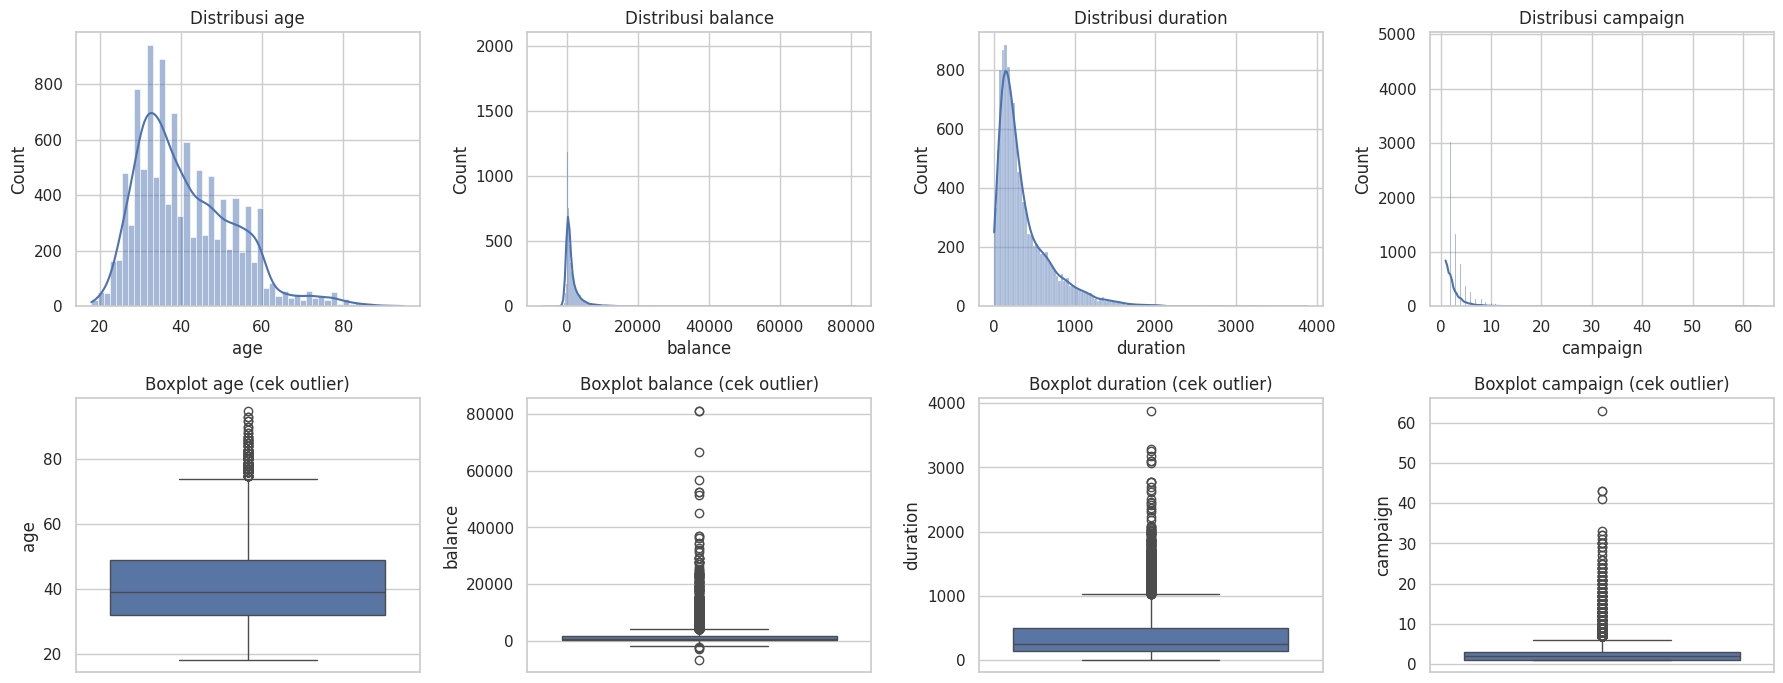

In [ ]:
numerical_features = ["age", "balance", "duration", "campaign"]
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for i, feature in enumerate(numerical_features):
    sns.histplot(df[feature], kde=True, ax=axes[0, i])
    axes[0, i].set_title(f"Distribusi {feature}")
    sns.boxplot(y=df[feature], ax=axes[1, i])
    axes[1, i].set_title(f"Boxplot {feature} (cek outlier)")
plt.tight_layout()
plt.show()

> Hubungan Fitur dengan Target

Tingkat keberhasilan (persentase Yes) per bulan dan per hasil kampanye sebelumnya menunjukkan pola yang kuat. Pola ini yang nantinya ditangkap model.

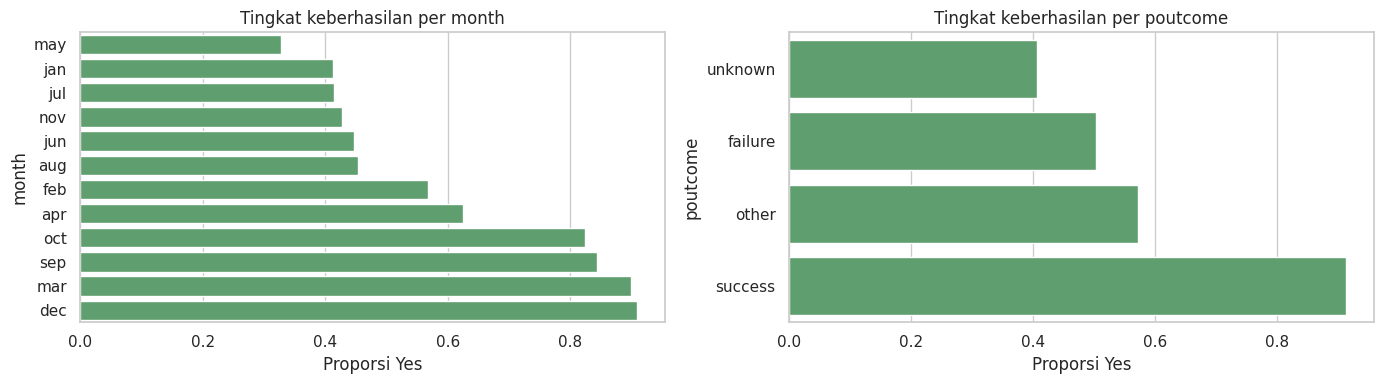

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col in zip(axes, ["month", "poutcome"]):
    rate = df.groupby(col)["deposit"].apply(lambda s: (s == "yes").mean()).sort_values()
    sns.barplot(x=rate.values, y=rate.index, color="#55A868", ax=ax)
    ax.set(title=f"Tingkat keberhasilan per {col}", xlabel="Proporsi Yes")
plt.tight_layout()
plt.show()

---
# ***Fase 3: Data Preparation***
---
### **Pembersihan dan Fitur Turunan**
Langkah di bawah tidak membutuhkan statistik data, sehingga aman dilakukan sebelum pemisahan data:
- nilai `unknown` pada `job`, `education`, dan `contact` diubah menjadi nilai kosong (diimputasi nanti di dalam pipeline);
- `pdays = -1` diubah menjadi nilai kosong, dan dibuat fitur `contacted_before`;
- dibuat fitur `has_loan_any` (memiliki KPR atau pinjaman pribadi);
- kolom `day` dan `previous` dibuang seperti pada versi awal, serta `duration` dibuang karena baru diketahui setelah panggilan.

In [ ]:
IMPUTE_UNKNOWN = ["job", "education", "contact"]
NUMERIC = ["age", "balance", "campaign", "pdays", "contacted_before", "has_loan_any"]
CATEGORICAL = ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "poutcome"]
FEATURES = NUMERIC + CATEGORICAL


def clean_and_engineer(data):
    data = data.copy()
    data[IMPUTE_UNKNOWN] = data[IMPUTE_UNKNOWN].replace("unknown", np.nan)
    data["pdays"] = data["pdays"].replace(-1, np.nan)
    data["contacted_before"] = data["pdays"].notna().astype(int)
    data["has_loan_any"] = ((data["housing"] == "yes") | (data["loan"] == "yes")).astype(int)
    return data


df_clean = clean_and_engineer(df.drop_duplicates())
X = df_clean[FEATURES]
y = df_clean["deposit"].map({"yes": 1, "no": 0})
print(X.shape, y.mean().round(3))

(11162, 15) 0.474


### **Train - Test Split**
Data dipisah lebih dulu (stratified 80/20). Statistik apa pun (median, batas outlier, rata-rata) hanya boleh dihitung dari data latih.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
pd.DataFrame({"Set": ["Training", "Testing"], "Shape": [str(X_train.shape), str(X_test.shape)],
              "Proporsi Yes": [y_train.mean().round(3), y_test.mean().round(3)]})

,Set,Shape,Proporsi Yes
0,Training,"(8929, 15)",0.474
1,Testing,"(2233, 15)",0.474


### **Preprocessing dalam Pipeline**
- **Numerik:** imputasi median → capping outlier `balance` (batas atas Q3 + 1,5 × IQR dari data latih) → standardisasi.
- **Kategorikal:** imputasi modus → one-hot encoding (kategori baru diabaikan, bukan error).

In [ ]:
class IQRCapper(BaseEstimator, TransformerMixin):
    """Batasi nilai di atas Q3 + 1.5 * IQR; batas dihitung hanya saat fit (data latih)."""

    def __init__(self, columns):
        self.columns = columns

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        q1, q3 = X[self.columns].quantile(0.25), X[self.columns].quantile(0.75)
        self.upper_ = q3 + 1.5 * (q3 - q1)
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for col in self.columns:
            X[col] = X[col].clip(upper=self.upper_[col])
        return X

    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features, dtype=object)


def make_preprocessor():
    numeric_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median").set_output(transform="pandas")),
        ("cap", IQRCapper(columns=["balance"])),
        ("scale", StandardScaler()),
    ])
    categorical_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    return ColumnTransformer([("num", numeric_pipe, NUMERIC), ("cat", categorical_pipe, CATEGORICAL)])

---
# ***Fase 4: Modeling***
---
Tiga model dibandingkan: **Logistic Regression** (baseline), **Random Forest**, dan **Gradient Boosting** (model final). Ketiganya dibungkus pipeline yang sama sehingga data baru dapat langsung diproses tanpa langkah manual.

In [ ]:
FINAL_MODEL = "Gradient Boosting (Final)"
estimators = {
    "Logistic Regression (Baseline)": LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    "Random Forest": RandomForestClassifier(
        random_state=RANDOM_STATE, n_estimators=200, n_jobs=-1, max_depth=10, min_samples_leaf=5),
    FINAL_MODEL: HistGradientBoostingClassifier(
        random_state=RANDOM_STATE, learning_rate=0.05, max_leaf_nodes=15,
        min_samples_leaf=40, l2_regularization=1.0, max_iter=200),
}
models = {name: Pipeline([("prep", make_preprocessor()), ("model", est)]) for name, est in estimators.items()}
for name, model in models.items():
    model.fit(X_train, y_train)
    print("Selesai dilatih:", name)

Selesai dilatih: Logistic Regression (Baseline)
Selesai dilatih: Random Forest
Selesai dilatih: Gradient Boosting (Final)


---
# ***Fase 5: Evaluation***
---
### **Evaluasi Model dengan Metrik Relevan**
Selain Precision dan Recall, evaluasi memakai metrik yang sesuai untuk lead scoring:
- **ROC-AUC:** kemampuan model mengurutkan nasabah potensial di atas yang tidak potensial.
- **Capture rate Top 20%:** persentase seluruh nasabah potensial yang terjangkau bila hanya 20% teratas dihubungi.
- **Precision Top 20%:** persentase nasabah yang benar-benar membuka deposito di antara 20% teratas.
- **Lift Top 20%:** precision Top 20% dibagi tingkat keberhasilan acak.

Interval kepercayaan 95% dihitung dengan bootstrap.

In [ ]:
def top_k_metrics(y_true, proba, frac=TOP_FRACTION):
    y_true = np.asarray(y_true)
    n_top = int(len(y_true) * frac)
    hits = y_true[np.argsort(-np.asarray(proba))[:n_top]].sum()
    precision_top = hits / n_top
    return hits / y_true.sum(), precision_top, precision_top / y_true.mean()


def bootstrap_ci(y_true, proba, n_boot=1000, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    y_true, proba = np.asarray(y_true), np.asarray(proba)
    aucs, tops = [], []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y_true), len(y_true))
        aucs.append(roc_auc_score(y_true[idx], proba[idx]))
        tops.append(top_k_metrics(y_true[idx], proba[idx])[1])
    return np.percentile(aucs, [2.5, 97.5]), np.percentile(tops, [2.5, 97.5])


rows, cms = [], {}
for name, model in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    cms[name] = [[tn, fp], [fn, tp]]
    capture, prec_top, lift = top_k_metrics(y_test, proba)
    auc_ci, top_ci = bootstrap_ci(y_test, proba)
    rows.append({
        "Model": name,
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba),
        "ROC-AUC 95% CI": f"{auc_ci[0]:.3f}-{auc_ci[1]:.3f}",
        "Capture Top 20%": capture,
        "Precision Top 20%": prec_top,
        "Precision Top 20% 95% CI": f"{top_ci[0]:.3f}-{top_ci[1]:.3f}",
        "Lift Top 20%": lift,
    })
results = pd.DataFrame(rows).set_index("Model")
results.round(3)

,Precision,Recall,ROC-AUC,ROC-AUC 95% CI,Capture Top 20%,Precision Top 20%,Precision Top 20% 95% CI,Lift Top 20%
Model,,,,,,,,
Logistic Regression (Baseline),0.722,0.547,0.745,0.726-0.765,0.361,0.857,0.823-0.888,1.808
Random Forest,0.769,0.547,0.757,0.738-0.776,0.358,0.850,0.821-0.886,1.794
Gradient Boosting (Final),0.779,0.555,0.766,0.747-0.785,0.369,0.874,0.841-0.904,1.846


> Confusion Matrix (ambang 0,5)

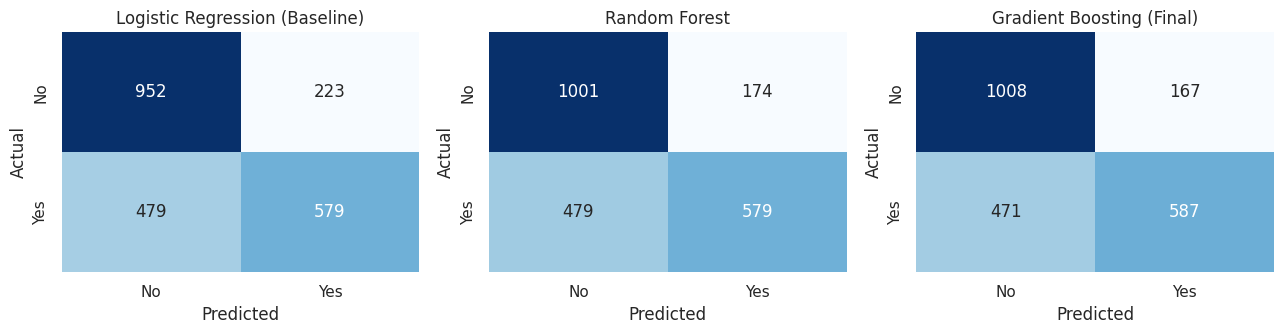

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, (name, cm) in zip(axes, cms.items()):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["No", "Yes"], yticklabels=["No", "Yes"], ax=ax)
    ax.set(title=name, xlabel="Predicted", ylabel="Actual")
plt.tight_layout()
plt.show()

> Kurva Gain

Semakin cepat kurva naik di atas garis diagonal (cold calling acak), semakin sedikit panggilan yang dibutuhkan untuk menjangkau nasabah potensial.

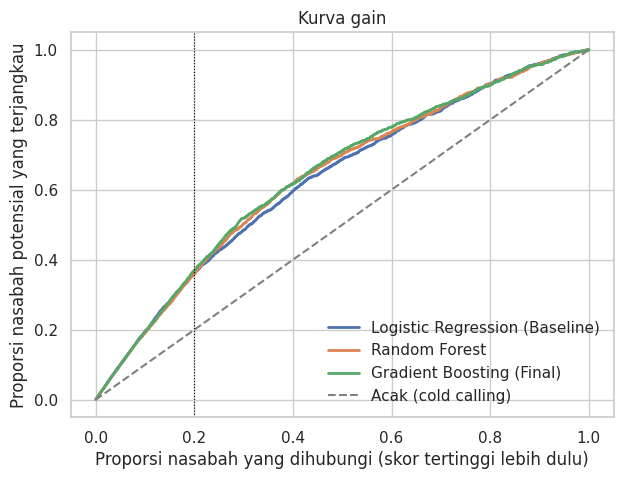

Menghubungi 20% nasabah teratas menjangkau 36.9% nasabah potensial
Menghubungi 40% nasabah teratas menjangkau 61.6% nasabah potensial
Menghubungi 60% nasabah teratas menjangkau 77.8% nasabah potensial
Menjangkau 50% nasabah potensial membutuhkan ±28.7% panggilan
Menjangkau 80% nasabah potensial membutuhkan ±63.6% panggilan


In [ ]:
y_arr = np.asarray(y_test)
fig, ax = plt.subplots(figsize=(7, 5))
for name, model in models.items():
    order = np.argsort(-model.predict_proba(X_test)[:, 1])
    gain = np.cumsum(y_arr[order]) / y_arr.sum()
    ax.plot(np.arange(1, len(y_arr) + 1) / len(y_arr), gain, label=name, lw=2)
ax.plot([0, 1], [0, 1], "--", color="grey", label="Acak (cold calling)")
ax.axvline(TOP_FRACTION, color="black", lw=0.8, ls=":")
ax.set(title="Kurva gain", xlabel="Proporsi nasabah yang dihubungi (skor tertinggi lebih dulu)",
       ylabel="Proporsi nasabah potensial yang terjangkau")
ax.legend(loc="lower right", frameon=False)
plt.show()

final = models[FINAL_MODEL]
order = np.argsort(-final.predict_proba(X_test)[:, 1])
cum = np.cumsum(y_arr[order]) / y_arr.sum()
for share in (0.2, 0.4, 0.6):
    print(f"Menghubungi {share:.0%} nasabah teratas menjangkau {cum[int(len(y_arr) * share) - 1]:.1%} nasabah potensial")
for goal in (0.5, 0.8):
    print(f"Menjangkau {goal:.0%} nasabah potensial membutuhkan ±{(np.argmax(cum >= goal) + 1) / len(y_arr):.1%} panggilan")

### **Interpretasi Hasil (Permutation Importance)**
Pentingnya fitur diukur dari penurunan ROC-AUC pada test set ketika nilai fitur diacak. Metode ini bekerja pada fitur asli (sebelum one-hot), sehingga lebih mudah ditafsirkan daripada importance bawaan model.

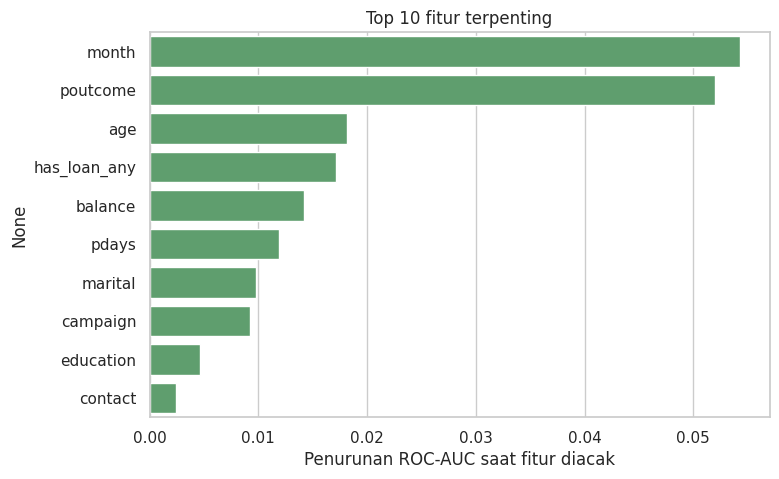

,Penurunan ROC-AUC
month,0.0543
poutcome,0.0520
age,0.0182
has_loan_any,0.0171
balance,0.0142
pdays,0.0119
marital,0.0098
campaign,0.0092
education,0.0047
contact,0.0024


In [ ]:
r = permutation_importance(final, X_test, y_test, scoring="roc_auc",
                           n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
importance = pd.Series(r.importances_mean, index=X_test.columns).nlargest(10)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=importance.values, y=importance.index, color="#55A868", ax=ax)
ax.set(title="Top 10 fitur terpenting", xlabel="Penurunan ROC-AUC saat fitur diacak")
plt.show()
importance.round(4).to_frame("Penurunan ROC-AUC")

### **Memilih Ambang Skor (Target Precision > 80%)**
Ambang dipilih dari prediksi *out-of-fold* pada data latih (validasi silang 5-fold), bukan dari test set, agar test set tetap menjadi ukuran yang jujur.

In [ ]:
oof = cross_val_predict(final, X_train, y_train, cv=5, method="predict_proba")[:, 1]
y_tr = np.asarray(y_train)
threshold = next(
    round(float(t), 2) for t in np.arange(0.40, 0.95, 0.01)
    if (oof >= t).sum() >= 50 and y_tr[oof >= t].mean() >= TARGET_PRECISION
)

proba_test = final.predict_proba(X_test)[:, 1]
selected = proba_test >= threshold
print(f"Ambang skor: {threshold}")
print(f"Pada test set: precision = {y_arr[selected].mean():.1%}, "
      f"nasabah dihubungi = {selected.mean():.1%}, "
      f"nasabah potensial terjangkau = {y_arr[selected].sum() / y_arr.sum():.1%}")

Ambang skor: 0.56
Pada test set: precision = 82.4%, nasabah dihubungi = 29.8%, nasabah potensial terjangkau = 51.8%


> Uji ke Data Baru (Lead Scoring)

Data mentah langsung dimasukkan ke pipeline; preprocessing tidak perlu dilakukan manual.

In [ ]:
new_customers = pd.DataFrame({
    "age": [35, 50], "job": ["management", "blue-collar"],
    "marital": ["married", "single"], "education": ["tertiary", "secondary"],
    "default": ["no", "no"], "balance": [8000.0, 100.0],
    "housing": ["no", "yes"], "loan": ["no", "yes"],
    "contact": ["cellular", "telephone"], "month": ["may", "feb"],
    "campaign": [1, 5], "pdays": [300, 50], "poutcome": ["success", "failure"],
})
proba_new = final.predict_proba(clean_and_engineer(new_customers)[FEATURES])[:, 1]
scored = new_customers[["age", "job", "balance"]].assign(
    Probability=proba_new.round(4),
    Rekomendasi=np.where(proba_new >= threshold, "Hubungi (prioritas)", "Tunda"),
)
scored

,age,job,balance,Probability,Rekomendasi
0,35,management,8000.0,0.9315,Hubungi (prioritas)
1,50,blue-collar,100.0,0.1639,Tunda


---
# ***Kesimpulan dan Catatan***
---
- Menghubungi hanya **20% nasabah dengan skor tertinggi** menghasilkan precision ±87% (acak: ±47%), lift ±1,85×, dan menjangkau ±37% nasabah potensial.
- Pada ambang skor yang dipilih dari validasi silang, precision mencapai >80% dengan menghubungi ±30% nasabah dan menjangkau ±51% nasabah potensial.
- **Gradient Boosting** memberi ROC-AUC tertinggi, tetapi selisih antarmodel tidak signifikan secara statistik; ketiga model layak dipakai.
- Faktor yang paling berpengaruh: `month`, `poutcome`, `has_loan_any`, `age`, dan `balance`. Faktor ini menunjukkan pola, bukan hubungan sebab-akibat.
- **Keterbatasan:** data berasal dari satu kampanye masa lalu (kemungkinan *selection bias*), dan belum ada informasi biaya per panggilan untuk menghitung dampak efisiensi dalam rupiah.